In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df_inside = pd.read_csv("indoortest.csv")
df_outside = pd.read_csv("simpletest.csv")
df_vent = pd.read_csv("newoutdoortest.csv")


# Shift time so it starts at 0
df_outside[time_column] = df_outside[time_column] - df_outside[time_column].iloc[0]
df_outside = df_outside[df_outside[time_column] > 70]
df_outside[time_column] = df_outside[time_column] - df_outside[time_column].iloc[0]

df_inside[time_column] = df_inside[time_column] - df_inside[time_column].iloc[0]
df_inside = df_inside[df_inside[time_column] > 5]
df_inside[time_column] = df_inside[time_column] - df_inside[time_column].iloc[0]

df_vent[time_column] = df_vent[time_column] - df_vent[time_column].iloc[0]
df_vent = df_vent[df_vent[time_column] > 90]
df_vent[time_column] = df_vent[time_column] - df_vent[time_column].iloc[0]

# Remove inside datapoints





data_columns = [col for col in df_inside.columns if col != time_column]

for col in data_columns:
    plt.figure()
    # Plot Outside
    if col in df_outside.columns:
        plt.plot(df_outside[time_column],
                 df_outside[col],
                 label="Outside")
    # Plot Inside
    if col in df_inside.columns:
        plt.plot(df_inside[time_column],
                 df_inside[col],
                 label="Inside")

    if col in df_vent.columns:
        plt.plot(df_vent[time_column],
                 df_vent[col],
                 label="Vent")
        
    plt.xlabel("Time (s)")
    plt.ylabel(col)
    plt.title(f"{col}: Inside vs Outside")
    plt.legend()
    plt.grid(True)
    plt.show()

IndexError: single positional indexer is out-of-bounds

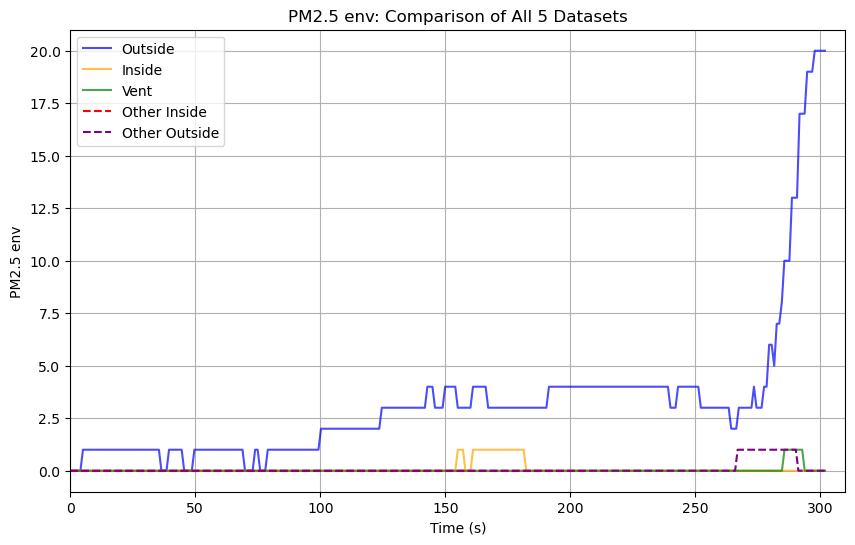

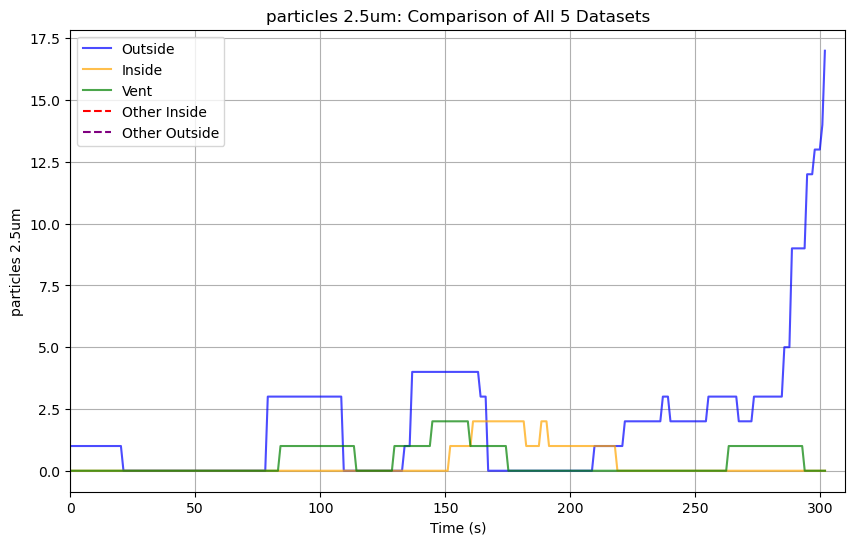

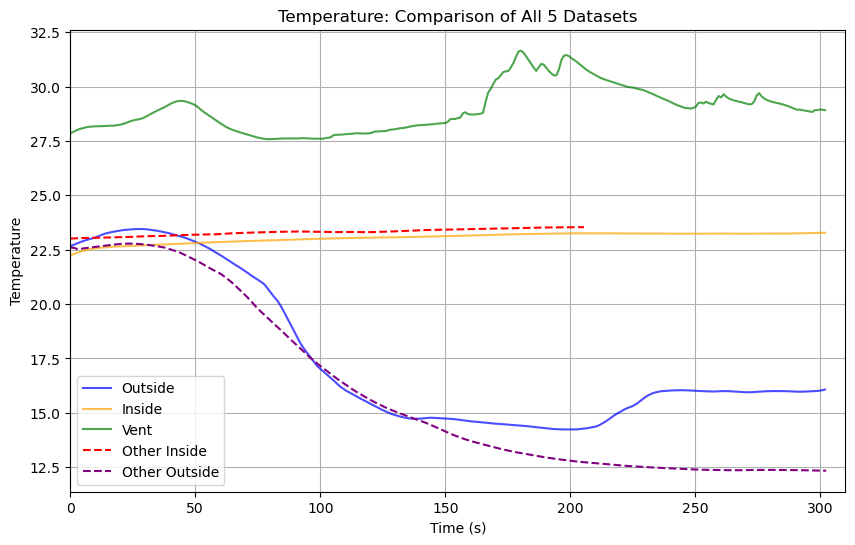

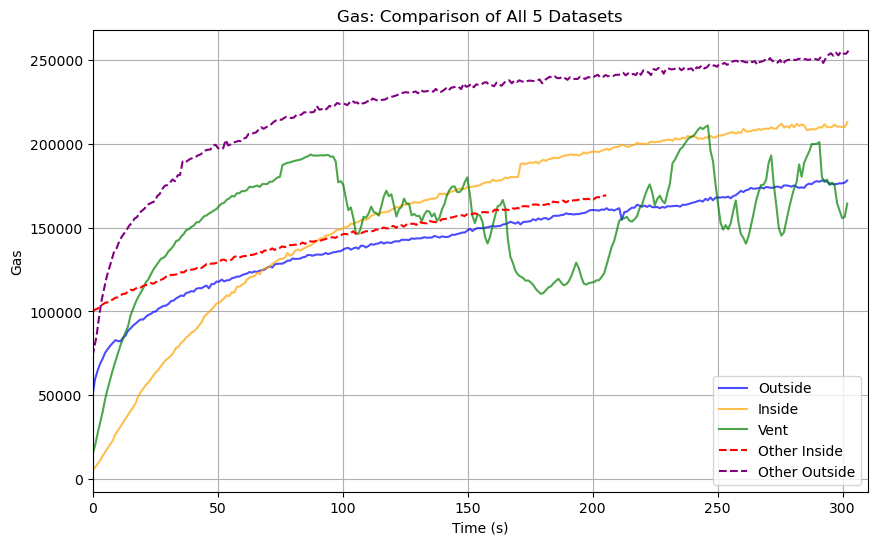

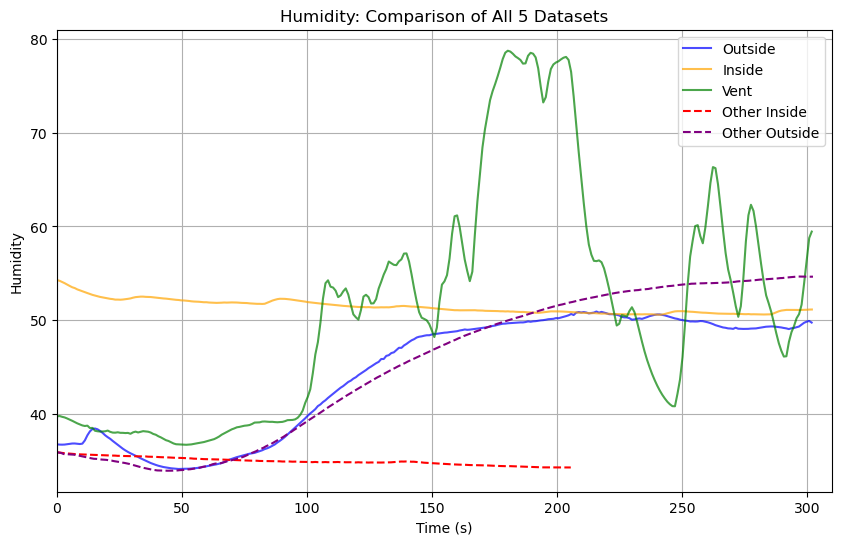

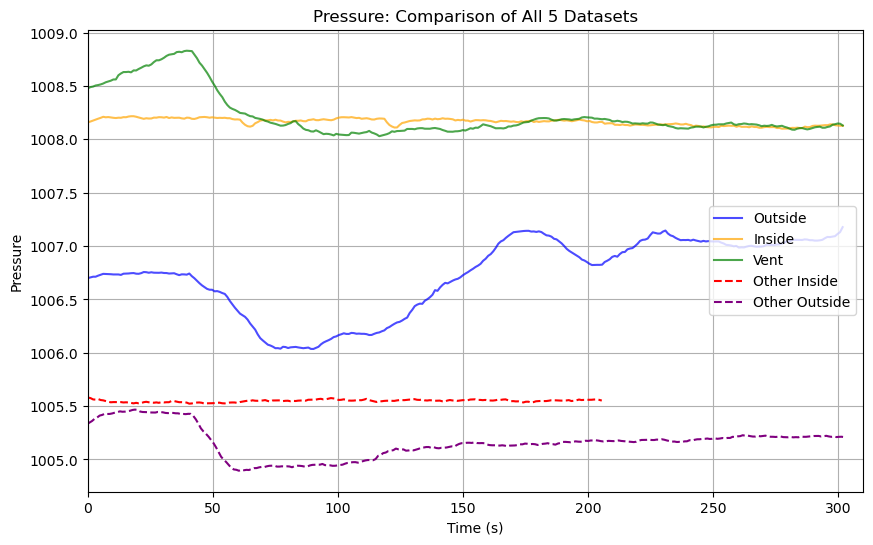

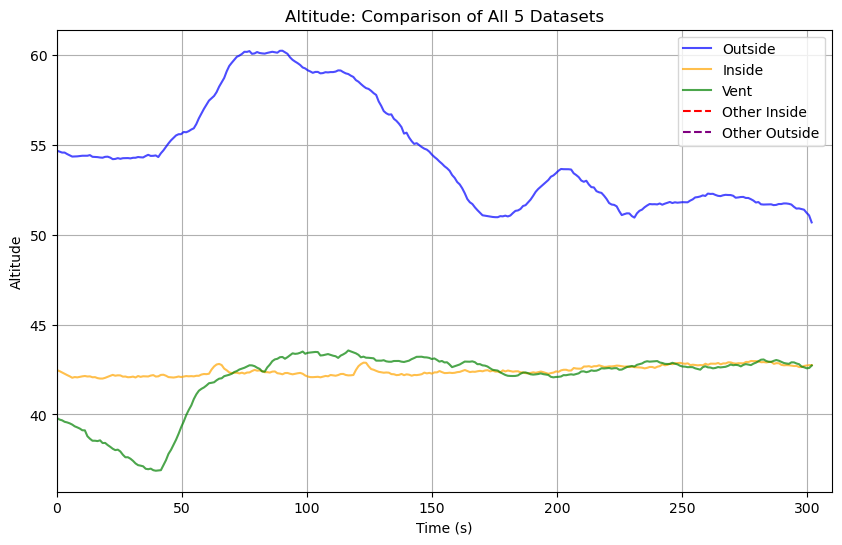

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load all data
df_inside = pd.read_csv("indoortest.csv")
df_outside = pd.read_csv("outdoortest.csv")
df_vent = pd.read_csv("newoutdoortest.csv")
df_other_inside = pd.read_csv("altindoor.csv")
df_other_outside = pd.read_csv("altoutdoor.csv")

# Drop the first row of the "Other" data because the sensors weren't ready
df_other_inside = df_other_inside.iloc[18:].reset_index(drop=True)
df_other_outside = df_other_outside.iloc[1:].reset_index(drop=True)
df_vent = df_vent.iloc[1:].reset_index(drop=True)
df_inside = df_inside.iloc[1:].reset_index(drop=True)
df_outside = df_outside.iloc[1:].reset_index(drop=True)

# 2. Setup Column Names & Mapping
time_col = 'time'
rename_dict = {'Timestamp': 'time', 'Temp': 'Temperature', 'PM25_Env': 'PM2.5 env'}

# 3. Standardize "Other" data structure
df_other_inside = df_other_inside.rename(columns=rename_dict)
df_other_outside = df_other_outside.rename(columns=rename_dict)

for df in [df_other_inside, df_other_outside]:
    df['particles 2.5um'] = np.nan
    df['Altitude'] = np.nan

# 4. CRITICAL: Reset Time for ALL dataframes to start at 0
all_dfs = [df_inside, df_outside, df_vent, df_other_inside, df_other_outside]

for df in all_dfs:
    if not df.empty and time_col in df.columns:
        # Subtract the very first timestamp from every row so start = 0
        df[time_col] = df[time_col] - df[time_col].iloc[0]

# --- Now run your plotting loop below ---

column_order = df_inside.columns

df_other_inside = df_other_inside[column_order]
df_other_outside = df_other_outside[column_order]

#display(df_other_inside)
#display(df_other_outside)
#display(df_inside)
#display(df_outside)
#display(df_vent)

# Define the colors for each dataset to keep it consistent
colors = {
    'Outside': 'blue',
    'Inside': 'orange',
    'Vent': 'green',
    'Other Inside': 'red',
    'Other Outside': 'purple'
}

# Use your primary dataframe's columns to determine what to plot
data_columns = [col for col in df_inside.columns if col != 'time']

# Shift "Other" group time so it starts at 0
if not df_other_inside.empty:
    df_other_inside['time'] = df_other_inside['time'] - df_other_inside['time'].iloc[0]

if not df_other_outside.empty:
    df_other_outside['time'] = df_other_outside['time'] - df_other_outside['time'].iloc[0]

for col in data_columns:
    plt.figure(figsize=(10, 6))
    
    # 1. Your Outside Data
    if col in df_outside.columns:
        plt.plot(df_outside['time'], df_outside[col], label="Outside", color=colors['Outside'], alpha=0.7)
        
    # 2. Your Inside Data
    if col in df_inside.columns:
        plt.plot(df_inside['time'], df_inside[col], label="Inside", color=colors['Inside'], alpha=0.7)
        
    # 3. Your Vent Data
    if col in df_vent.columns:
        plt.plot(df_vent['time'], df_vent[col], label="Vent", color=colors['Vent'], alpha=0.7)
        
    # 4. Other Group Inside (Note: these may have NaNs for Altitude/Particles)
    if col in df_other_inside.columns:
        plt.plot(df_other_inside['time'], df_other_inside[col], label="Other Inside", color=colors['Other Inside'], linestyle='--')
        
    # 5. Other Group Outside
    if col in df_other_outside.columns:
        plt.plot(df_other_outside['time'], df_other_outside[col], label="Other Outside", color=colors['Other Outside'], linestyle='--')

    plt.xlabel("Time (s)")
    plt.ylabel(col)
    plt.title(f"{col}: Comparison of All 5 Datasets")
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 310)
    plt.show()

In [17]:
display(df_other_outside)

,time,PM2.5 env,particles 2.5um,Temperature,Gas,Humidity,Pressure,Altitude
0,0.000000,0,NaN,34.466719,245806,100.000000,632.328927,NaN
1,1.012879,0,NaN,22.601875,73229,35.869937,1005.337374,NaN
2,2.629975,0,NaN,22.580195,85308,35.800706,1005.360672,NaN
3,3.641225,0,NaN,22.531758,96759,35.684219,1005.381465,NaN
4,4.652308,0,NaN,22.532734,106680,35.667547,1005.393336,NaN
...,...,...,...,...,...,...,...,...
295,299.349085,0,NaN,12.349141,252957,54.633212,1005.214850,NaN
296,300.362249,0,NaN,12.345430,255184,54.626581,1005.209996,NaN
297,301.375109,0,NaN,12.342891,254066,54.632455,1005.212207,NaN
298,302.386637,0,NaN,12.339570,253880,54.632052,1005.213046,NaN


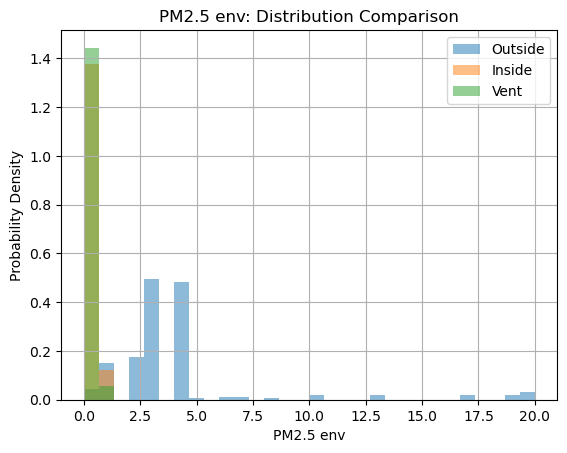

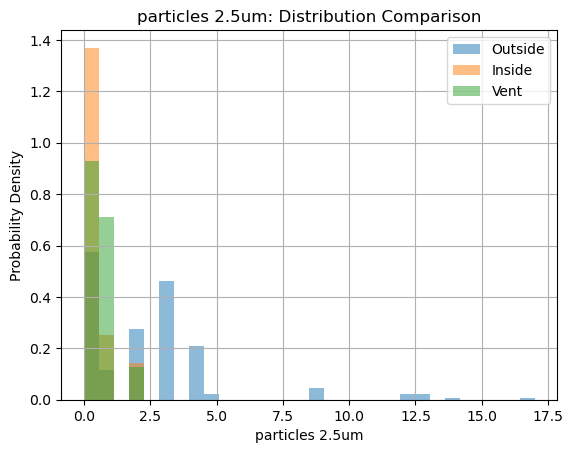

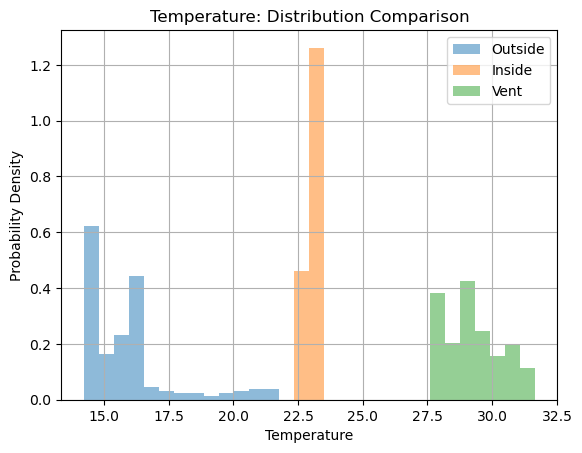

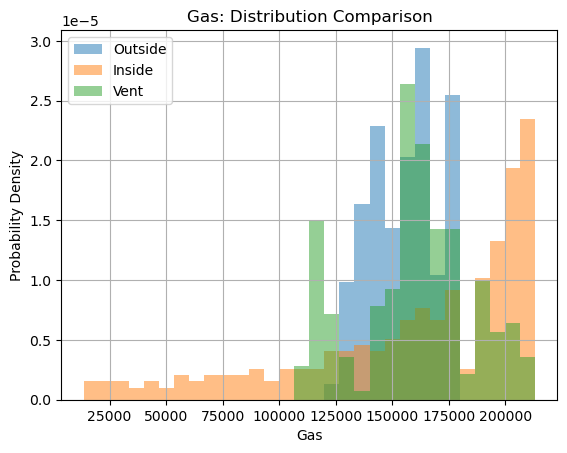

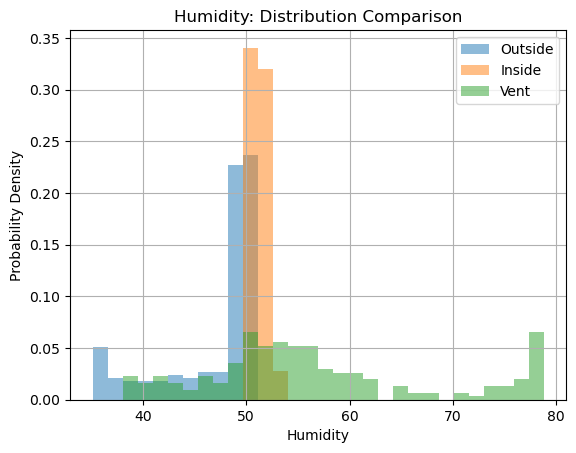

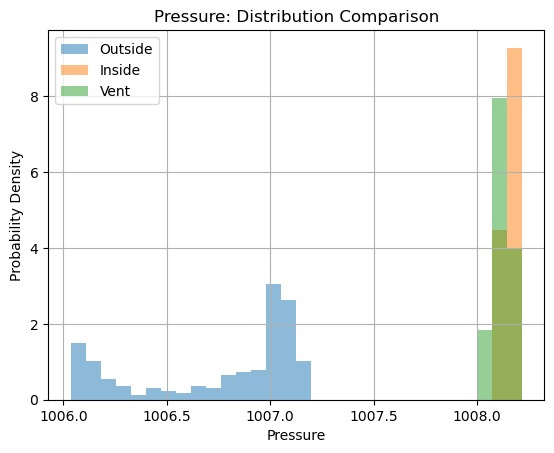

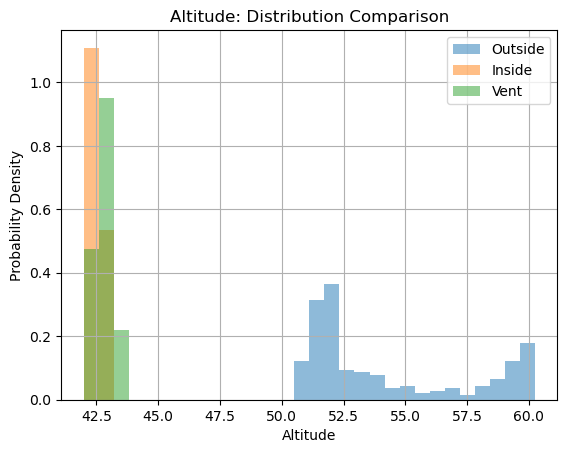

In [54]:
import matplotlib.pyplot as plt
import numpy as np

data_columns = [col for col in df_inside.columns if col != time_column]

for col in data_columns:
    plt.figure()

    # Collect all available data to define common bins
    combined = []

    if col in df_outside.columns:
        combined.append(df_outside[col].dropna())

    if col in df_inside.columns:
        combined.append(df_inside[col].dropna())

    if col in df_vent.columns:
        combined.append(df_vent[col].dropna())

    if not combined:
        continue
    combined = np.concatenate(combined)
    
    bins = np.histogram_bin_edges(combined, bins=30)

    if col in df_outside.columns:
        plt.hist(df_outside[col].dropna(),
                 bins=bins,
                 alpha=0.5,
                 label="Outside",
                 density=True)

    if col in df_inside.columns:
        plt.hist(df_inside[col].dropna(),
                 bins=bins,
                 alpha=0.5,
                 label="Inside",
                 density=True)

    if col in df_vent.columns:
        plt.hist(df_vent[col].dropna(),
                 bins=bins,
                 alpha=0.5,
                 label="Vent",
                 density=True)

    plt.xlabel(col)
    plt.ylabel("Probability Density")
    plt.title(f"{col}: Distribution Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

In [22]:
import pandas as pd
import numpy as np

# Split: inside is (1, 40] seconds, outside is > 40 seconds
df_inside  = df[(df[time_column] > 1) & (df[time_column] <= 40)]
df_outside = df[df[time_column] > 40]

results = []

for col in df.columns[1:]:
    xin = df_inside[col].dropna().to_numpy()
    xout = df_outside[col].dropna().to_numpy()

    Nin, Nout = len(xin), len(xout)
    
    mu_in, mu_out = xin.mean(), xout.mean()

    # sample std dev
    sigma_in  = xin.std(ddof=1)
    sigma_out = xout.std(ddof=1)

    # uncertainty on the mean
    sigma_in_uncertainty  = sigma_in / np.sqrt(Nin)
    sigma_out_uncertainty = sigma_out / np.sqrt(Nout)

    #how many inside measurement sigmas away are the two means

    uncertainty_difference = np.abs(mu_in-mu_out)/sigma_in

    results.append({
        "column": col,
        "N_in": Nin, "N_out": Nout,
        "mean_in": mu_in, "mean_out": mu_out,
        "std_in": sigma_in, "std_out": sigma_out,
        "sigma_in_uncertainty": sigma_in_uncertainty, "sigma_out_uncertainty": sigma_out_uncertainty,
        "inside_sigmas_difference": uncertainty_difference
    })

out = pd.DataFrame(results)
# Nice display ordering (optional)
cols_order = ["column","N_in","N_out","mean_in","mean_out","std_in","std_out","sigma_in_uncertainty", "sigma_out_uncertainty","inside_sigmas_difference"]
cols_order = [c for c in cols_order if c in out.columns]
out = out[cols_order]

print(out.to_string(index=False))

         column  N_in  N_out      mean_in      mean_out       std_in      std_out  sigma_in_uncertainty  sigma_out_uncertainty  inside_sigmas_difference
      PM2.5 env    35    260     0.885714      3.626923     0.322803     3.738979              0.054564               0.231882                  8.491898
particles 2.5um    35    260     0.485714      2.115385     0.507093     2.745680              0.085714               0.170280                  3.213753
    Temperature    35    260    23.275106     16.614220     0.182107     2.676792              0.030782               0.166008                 36.576752
            Gas    35    260 95063.971429 150852.396154 11342.012563 17876.661847           1917.150035            1108.663504                  4.918741
       Humidity    35    260    36.603784     45.510078     1.124208     5.958941              0.190026               0.369558                  7.922286
       Pressure    35    260  1006.741480   1006.720374     0.008150     0.380405 